# Preprocessat
Primer preprocessem

🧠 1) HOW EVERYTHING RELATES (THE SCHEMA)

Right now you have 3 “layers” of data:

📦 A. Raw images (DICOM files)

Located in:

cbis_ddsm/raw/cbis_ddsm/<FOLDER>/<Study>/<Series>/*.dcm

Each .dcm = one image

📊 B. Case description CSVs (THE IMPORTANT ONES)

You have:

calc_case_description_*
mass_case_description_*

These are your labels + metadata

Each row = one lesion (abnormality)

🔗 C. The link between them (CRUCIAL)

Each row contains:

image file path → original image
cropped image file path → cropped lesion image
ROI mask file path → segmentation mask

👉 These paths map directly to your folders.

🧩 FULL RELATIONSHIP (THIS IS YOUR MENTAL MODEL)
PATIENT (patient_id)
   ↓
STUDY (StudyInstanceUID)
   ↓
SERIES (SeriesInstanceUID)
   ↓
IMAGE (.dcm file)
   ↑
CSV row (labels + metadata)

And more concretely:

CSV row
 ├── pathology → label (BENIGN / MALIGNANT)
 ├── image file path → full mammogram
 ├── cropped image file path → lesion crop
 └── ROI mask file path → segmentation
⚠️ IMPORTANT INSIGHT

👉 You should NOT use the full images first

Use:

cropped image file path (best for classification)
ROI mask file path (for segmentation or attention)

In [16]:
import matplotlib
import sklearn
import timm
import cv2
import gtda
import tqdm
import pydicom
import numpy as np
import yaml
import random
import torch 
from tqdm import tqdm

SEED = 2
np.random.seed(SEED)
random.seed(SEED)
print("All good ✅")

All good ✅


In [2]:
import pandas as pd

mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [3]:
calc_train_df = pd.read_csv('data/raw/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('data/raw/calc_case_description_test_set.csv')
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [4]:
metadata_df = pd.read_csv('data/raw/metadata/metadata.csv')
metadata_df.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status
0,Calc-Test_P_01004_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success
4,Calc-Test_P_00485_LEFT_CC_3,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success


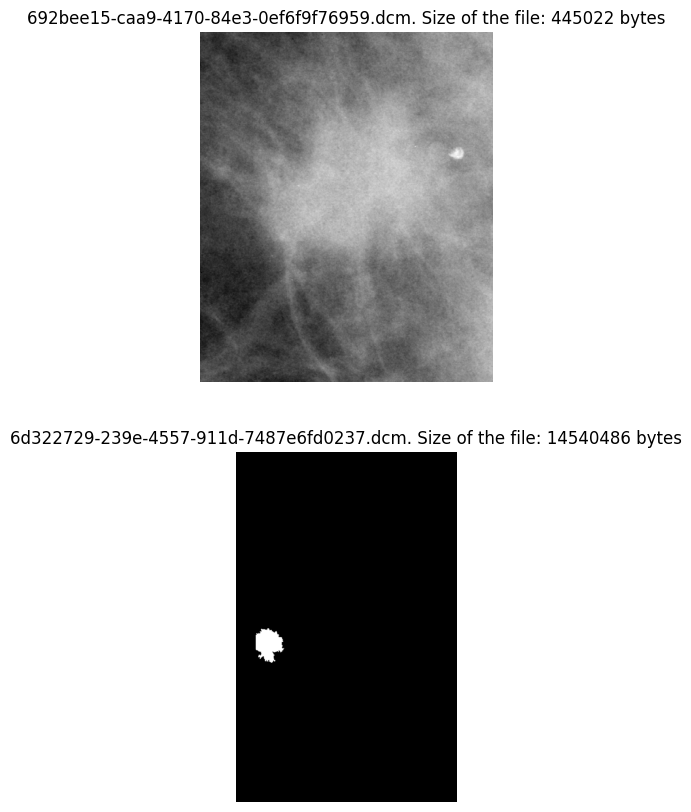

In [5]:
import matplotlib.pyplot as plt
import os
from src.utils.image_utils import load_dicom, resolve_dicom_path

BASE_PATH = r"C:/Users/esthe/Documents/UOC/TFM/TDA_Visual_Transformer/data/raw/cbis_ddsm"

row = mass_train_df.iloc[0]

rel_path = row["cropped image file path"]

rel_path = rel_path.strip()
folder = os.path.dirname(rel_path)

full_folder = os.path.join(BASE_PATH, folder)
full_folder = r"\\?\{}".format(os.path.abspath(full_folder))

dcm_files = [f for f in os.listdir(full_folder) if f.endswith(".dcm")]

img_0_path = os.path.join(full_folder, dcm_files[0])
img_0 = load_dicom(img_0_path)
img_1_path = os.path.join(full_folder, dcm_files[1])
img_1 = load_dicom(img_1_path)

plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
plt.imshow(img_0, cmap="gray")
plt.title(dcm_files[0] + ". Size of the file: " + str(os.path.getsize(img_0_path)) + " bytes")
plt.axis("off")

plt.subplot(2,1,2)
plt.imshow(img_1, cmap="gray")
plt.title(dcm_files[1] + ". Size of the file: " + str(os.path.getsize(img_1_path)) + " bytes")
plt.axis("off")

plt.show()

This is a really important design decision, and it directly affects your results and how strong your thesis looks.

Let’s be very clear:

You have:

Cropped image → the actual mammogram region
ROI mask → binary mask showing lesion location
🧠 Short answer (practical recommendation)

👉 Use:

ViT input → cropped image
Preprocessing → cropped image
TDA → cropped image (main) + optionally masked version (advanced)

👉 Use the ROI mask ONLY as guidance, not as main input (at least initially)

🔍 Why this is the correct baseline choice

Your thesis goal is:

Improve classification using preprocessing + TDA

NOT:

Build a segmentation-aware model

So:

The model should see the same type of input as prior work
ROI masks are extra information, not the core signal
📊 What each file represents
🖼️ Cropped image
Contains:
Tumor
Surrounding tissue
What models usually train on

👉 This is your primary input

🎯 ROI mask
Binary (0/1)
Highlights lesion area

👉 This is spatial prior knowledge

⚙️ How to use them properly
✅ 1. Visual Transformer (ViT)

Use:

INPUT = cropped image

Why:

ViT expects natural image-like input
Mask alone has no texture → useless for classification
✅ 2. Preprocessing

Apply preprocessing to:

cropped image ONLY

Example:

CLAHE
Denoising

👉 Do NOT preprocess the mask

⚠️ 3. TDA — this is where it gets interesting

You have 3 possible strategies:

🥇 Option A (recommended baseline)

👉 TDA on raw cropped image

image → persistence diagram → persistence image

✔ Simple
✔ Matches your thesis description
✔ Works well

🥈 Option B (better, still clean)

👉 Apply mask BEFORE TDA:

masked_image = image * ROI_mask

Then:

masked_image → TDA

✔ Focuses topology on lesion
✔ Removes background noise
✔ Very relevant for medical images

👉 This is a strong experiment idea

🥉 Option C (advanced / bonus)

Use BOTH:

TDA on full image
TDA on masked image

Then concatenate features

👉 This becomes a nice contribution if you have time

Label: BENIGN
Path length: 281


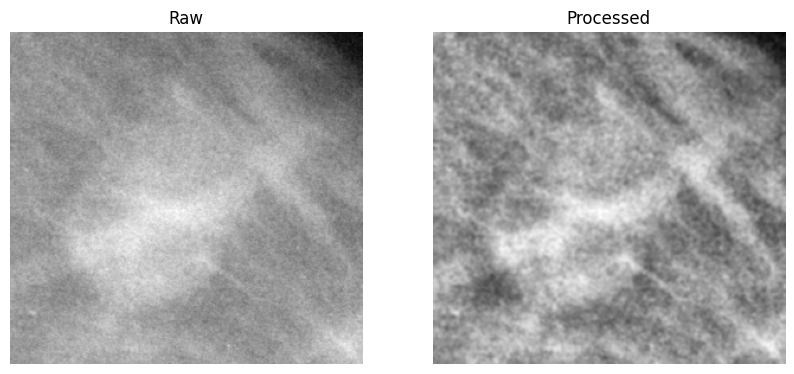

In [6]:
import matplotlib.pyplot as plt
from src.preprocessing.preprocess import preprocess

row = mass_train_df.iloc[10]

rel_path = row["cropped image file path"]

img_path = resolve_dicom_path(rel_path)
img_raw = load_dicom(img_path)
img_processed = preprocess(img_raw)

label = row["pathology"]

print("Label:", label)
print("Path length:", len(img_path))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_raw, cmap="gray")
plt.title("Raw")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

Label: MALIGNANT
Path length: 282


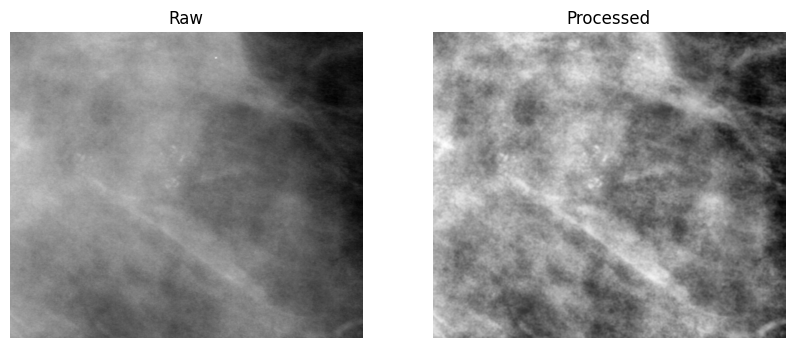

In [7]:
import matplotlib.pyplot as plt
from src.preprocessing.preprocess import preprocess

row = calc_train_df.iloc[0]

rel_path = row["cropped image file path"]

img_path = resolve_dicom_path(rel_path)
img_raw = load_dicom(img_path)
img_processed = preprocess(img_raw)

label = row["pathology"]

print("Label:", label)
print("Path length:", len(img_path))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_raw, cmap="gray")
plt.title("Raw")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

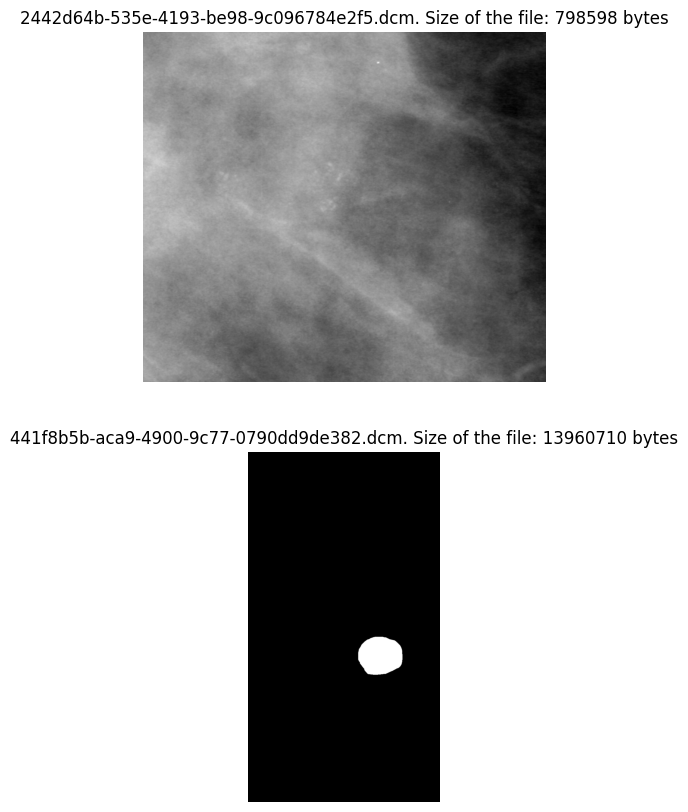

In [8]:
import matplotlib.pyplot as plt
import os

BASE_PATH = r"C:/Users/esthe/Documents/UOC/TFM/TDA_Visual_Transformer/data/raw/cbis_ddsm"

row = calc_train_df.iloc[0]

rel_path = row["cropped image file path"]

rel_path = rel_path.strip()
folder = os.path.dirname(rel_path)

full_folder = os.path.join(BASE_PATH, folder)
full_folder = r"\\?\{}".format(os.path.abspath(full_folder))

dcm_files = [f for f in os.listdir(full_folder) if f.endswith(".dcm")]

img_0_path = os.path.join(full_folder, dcm_files[0])
img_0 = load_dicom(img_0_path)
img_1_path = os.path.join(full_folder, dcm_files[1])
img_1 = load_dicom(img_1_path)

plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
plt.imshow(img_0, cmap="gray")
plt.title(dcm_files[0] + ". Size of the file: " + str(os.path.getsize(img_0_path)) + " bytes")
plt.axis("off")

plt.subplot(2,1,2)
plt.imshow(img_1, cmap="gray")
plt.title(dcm_files[1] + ". Size of the file: " + str(os.path.getsize(img_1_path)) + " bytes")
plt.axis("off")

plt.show()

You asked:

should I use calc or mass?

👉 Start with MASS only

Why:

Mass lesions have clearer structure → better for both ViT and TDA
Calcifications are:
smaller
noisier
harder → can hurt early experiments

👉 Strategy:

Phase 1: MASS (E1–E8)
Phase 2 (optional): add CALC as extension

E1


In [15]:
import pandas as pd

mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')

def encode_label(label):
    return 1 if label == "MALIGNANT" else 0

In [18]:
import os
import numpy as np

SAVE_DIR = "data/processed/mass"
os.makedirs(SAVE_DIR, exist_ok=True)

image_paths = []
labels = []
cached_paths = []

for i, row in tqdm(mass_train_df.iterrows()):
    try:
        rel_path = row["cropped image file path"]
        full_path = resolve_dicom_path(rel_path)

        label = encode_label(row["pathology"])

        image_paths.append(full_path)
        labels.append(label)

        try:
            img = load_dicom(full_path)

            save_path = os.path.join(SAVE_DIR, f"img_{i}.npy")
            np.save(save_path, img)

            cached_paths.append(save_path)

        except Exception as e:
            print("Error:", e)

    except Exception as e:
        print("Skipping:", e)
        
    row

cache_df = pd.DataFrame({
    "path": cached_paths,
    "label": labels
})

cache_df.to_csv("data/processed/mass_train_cached.csv", index=False)

111it [00:00, 374.62it/s]

232it [00:00, 388.52it/s]

353it [00:00, 389.21it/s]

514it [00:01, 385.86it/s]

633it [00:01, 377.24it/s]

...

892it [00:02, 371.37it/s]

1003it [00:02, 353.87it/s]

1075it [00:02, 345.29it/s]

1246it [00:03, 399.97it/s]

1318it [00:03, 379.42it/s]

In [11]:
from torch.utils.data import DataLoader
from src.datasets.dataset import MammographyDataset

cache_df = pd.read_csv("data/processed/mass_train_cached.csv")

image_paths = cache_df["path"].tolist()
labels = cache_df["label"].tolist()

dataset = MammographyDataset(cached_paths, labels)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [12]:
from src.models.vit_model import ViTClassifier
import torch

print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ViTClassifier().to(device)

batch = next(iter(dataloader))
x, y = batch

x = x.to(device)

outputs = model(x)

print(outputs.shape)  # should be [batch_size, 1]

True


torch.Size([9, 1])


In [13]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

model.train()

for epoch in range(3):  # start small
    total_loss = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        outputs = model(x).squeeze()

        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader)}")

Epoch 1, Loss: 0.6769787669181824
Epoch 2, Loss: 0.9553728103637695
Epoch 3, Loss: 0.9304489493370056


In [14]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in dataloader:
        x = x.to(device)

        outputs = model(x).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()

        y_pred.extend(probs)
        y_true.extend(y.numpy())

y_pred_bin = [1 if p > 0.5 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred_bin))
print("F1:", f1_score(y_true, y_pred_bin))
print("AUC:", roc_auc_score(y_true, y_pred))

Accuracy: 0.5555555555555556
F1: 0.7142857142857143
AUC: 0.44999999999999996


end of e1

In [12]:
from torch.utils.data import DataLoader
from src.datasets.dataset import MammographyDataset

dataset = MammographyDataset(image_paths, labels)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

from src.models.vit_model import ViTClassifier
import torch

print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ViTClassifier().to(device)

batch = next(iter(dataloader))
x, y = batch

x = x.to(device)

outputs = model(x)

print(outputs.shape)  # should be [batch_size, 1]

True
torch.Size([9, 1])


In [13]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

model.train()

for epoch in range(3):  # start small
    total_loss = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        outputs = model(x).squeeze()

        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader)}")

Epoch 1, Loss: 0.734217643737793
Epoch 2, Loss: 2.146857976913452
Epoch 3, Loss: 0.531261146068573


In [14]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in dataloader:
        x = x.to(device)

        outputs = model(x).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()

        y_pred.extend(probs)
        y_true.extend(y.numpy())

y_pred_bin = [1 if p > 0.5 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred_bin))
print("F1:", f1_score(y_true, y_pred_bin))
print("AUC:", roc_auc_score(y_true, y_pred))

Accuracy: 0.5555555555555556
F1: 0.7142857142857143
AUC: 1.0


#### testing zone

2.12.0.dev20260408+cu128


All good ✅
